<a href="https://colab.research.google.com/github/tomarjyoti16/assignment-02-bitsom_ba_2511563/blob/main/part4-vector-db/embeddings_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install sentence-transformers seaborn matplotlib scikit-learn

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
sentences = [
    # Cricket (4 sentences)
    "The batsman scored a century in the final match",
    "The bowler delivered a fast yorker to dismiss the player",
    "The team celebrated their victory after winning the series",
    "Fielders were placed strategically to stop boundaries",

    # Cooking (3 sentences)
    "The chef prepared a delicious pasta with fresh ingredients",
    "Baking requires precise measurements of flour and sugar",
    "The recipe calls for simmering the sauce for 20 minutes",

    # Cybersecurity (3 sentences)
    "The system detected a malware attack in the network",
    "Strong passwords help prevent unauthorized access",
    "Encryption ensures data is secure during transmission"
]

len(sentences)

10

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

print("Embedding shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (10, 384)


In [ ]:
similarity_matrix = cosine_similarity(embeddings)

# Convert to DataFrame for better visualization
df = pd.DataFrame(similarity_matrix, index=sentences, columns=sentences)

dfsimilarity_matrix = cosine_similarity(embeddings)

# Convert to DataFrame for better visualization
df = pd.DataFrame(similarity_matrix, index=sentences, columns=sentences)

df

,The batsman scored a century in the final match,The bowler delivered a fast yorker to dismiss the player,The team celebrated their victory after winning the series,Fielders were placed strategically to stop boundaries,The chef prepared a delicious pasta with fresh ingredients,Baking requires precise measurements of flour and sugar,The recipe calls for simmering the sauce for 20 minutes,The system detected a malware attack in the network,Strong passwords help prevent unauthorized access,Encryption ensures data is secure during transmission
The batsman scored a century in the final match,1.000000,0.364915,0.311483,0.262705,-0.019168,0.150191,0.055601,0.146510,-0.063650,0.023732
The bowler delivered a fast yorker to dismiss the player,0.364915,1.000000,0.181166,0.362833,0.077110,0.028979,0.082031,0.163029,-0.035915,0.056555
The team celebrated their victory after winning the series,0.311483,0.181166,1.000000,0.213418,0.032180,-0.046327,0.028021,0.155571,0.024770,0.047359
Fielders were placed strategically to stop boundaries,0.262705,0.362833,0.213418,1.000000,-0.069711,0.040675,-0.014110,0.069559,0.076761,0.082036
The chef prepared a delicious pasta with fresh ingredients,-0.019168,0.077110,0.032180,-0.069711,1.000000,0.192899,0.347277,0.197997,0.017295,0.043071
Baking requires precise measurements of flour and sugar,0.150191,0.028979,-0.046327,0.040675,0.192899,1.000000,0.151565,0.002126,-0.042323,0.084438
The recipe calls for simmering the sauce for 20 minutes,0.055601,0.082031,0.028021,-0.014110,0.347277,0.151565,1.000000,0.095155,-0.037204,0.001622
The system detected a malware attack in the network,0.146510,0.163029,0.155571,0.069559,0.197997,0.002126,0.095155,1.000000,0.128896,0.100641
Strong passwords help prevent unauthorized access,-0.063650,-0.035915,0.024770,0.076761,0.017295,-0.042323,-0.037204,0.128896,1.000000,0.222932
Encryption ensures data is secure during transmission,0.023732,0.056555,0.047359,0.082036,0.043071,0.084438,0.001622,0.100641,0.222932,1.000000


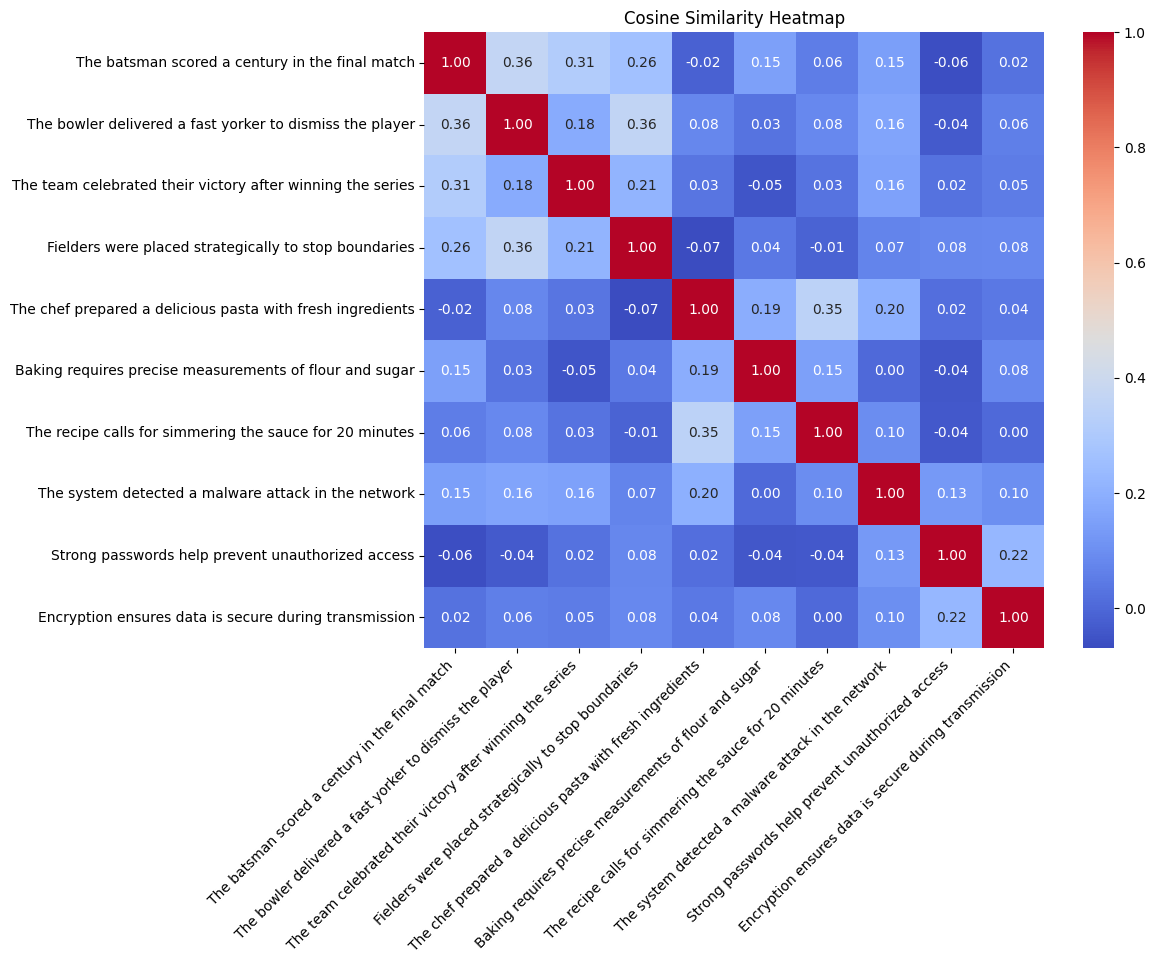

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Cosine Similarity Heatmap")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

In [ ]:
query = "The bowler took three wickets in one over"

# Encode query
query_embedding = model.encode([query])

# Compute similarity with all sentences
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 most similar sentences
top_indices = query_similarities.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 most similar sentences:\n")

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {query_similarities[idx]:.4f}\n")

Query: The bowler took three wickets in one over

Top 2 most similar sentences:

Sentence: The batsman scored a century in the final match
Similarity Score: 0.5707

Sentence: The bowler delivered a fast yorker to dismiss the player
Similarity Score: 0.5078

